in this part i will try my best to make clasification model

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt

In [2]:
# Generate spiral data
def make_spirals(n_samples=1000, n_classes=3, noise=0.1, random_state=42):
    np.random.seed(random_state)
    X = []
    y = []
    n_per_class = n_samples // n_classes
    for c in range(n_classes):
        t = np.linspace(0, 4 * np.pi, n_per_class)
        r = t / (4 * np.pi)
        angle = t + (2 * np.pi * c / n_classes)
        x1 = r * np.cos(angle) + np.random.randn(n_per_class) * noise
        x2 = r * np.sin(angle) + np.random.randn(n_per_class) * noise
        X.append(np.stack([x1, x2], axis=1))
        y.append(np.full(n_per_class, c))
    return np.vstack(X), np.concatenate(y)

X, y = make_spirals(n_samples=1000, n_classes=3, noise=0.05)
X[:5],y[:5]

(array([[ 0.02483571, -0.03385809],
        [-0.00390332,  0.04886997],
        [ 0.03839127, -0.00689727],
        [ 0.08512944, -0.040251  ],
        [ 0.0002027 , -0.01425213]]),
 array([0, 0, 0, 0, 0]))

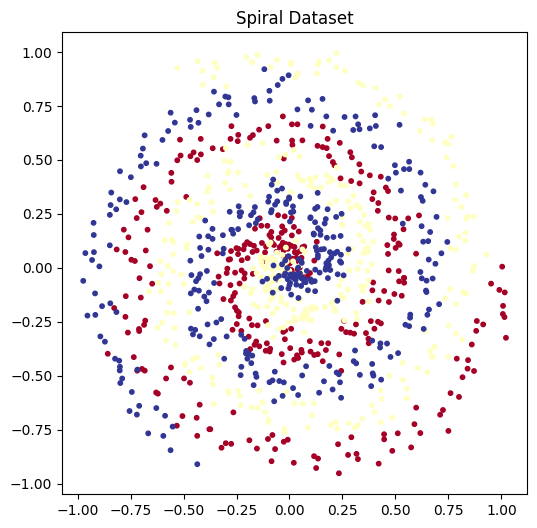

In [3]:


# Visualize
plt.figure(figsize=(6,6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='RdYlBu', s=10)
plt.title("Spiral Dataset")
plt.show()

In [4]:
x=torch.tensor(X, dtype=torch.float32)
y=torch.tensor(y, dtype=torch.long)
x[:5],y[:5]

(tensor([[ 0.0248, -0.0339],
         [-0.0039,  0.0489],
         [ 0.0384, -0.0069],
         [ 0.0851, -0.0403],
         [ 0.0002, -0.0143]]),
 tensor([0, 0, 0, 0, 0]))

In [5]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)


In [6]:
device = "cuda" if torch.cuda.is_available() else "cpu"
x_train, y_train = x_train.to(device), y_train.to(device)
x_test, y_test = x_test.to(device), y_test.to(device)
x_train.shape, y_train.shape

(torch.Size([799, 2]), torch.Size([799]))

In [83]:
from torch import nn

class SpiralModel(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.sequential = nn.Sequential(
            nn.Linear(2, 64),
            nn.ReLU(),
             nn.Dropout(0.1),
            nn.Linear(64, 64),
            nn.ReLU(),
             nn.Dropout(0.1),
             nn.Linear(64, 64),
            nn.ReLU(),
             nn.Dropout(0.1),
             nn.Linear(64, 64),
            nn.ReLU(),
             nn.Dropout(0.1),
            nn.Linear(64, 3)
        )

    def forward(self, x :torch.Tensor)->torch.Tensor:
        return self.sequential(x)
    


In [84]:
model = SpiralModel().to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
model

SpiralModel(
  (sequential): Sequential(
    (0): Linear(in_features=2, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=64, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.1, inplace=False)
    (6): Linear(in_features=64, out_features=64, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.1, inplace=False)
    (9): Linear(in_features=64, out_features=64, bias=True)
    (10): ReLU()
    (11): Dropout(p=0.1, inplace=False)
    (12): Linear(in_features=64, out_features=3, bias=True)
  )
)

In [85]:
epochs =1000

for epoch in range(epochs):
    model.train()
    y_pred = model(x_train)
    loss = loss_fn(y_pred, y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if epoch % 200 == 0:
        print(f"Epoch {epoch} | Loss: {loss.item():.4f} | Accuracy: {(y_pred.argmax(dim=1) == y_train).float().mean().item():.4f}")
model.eval()
with torch.inference_mode():
    test_pred = model(x_test)
    test_acc = (test_pred.argmax(dim=1) == y_test).float().mean().item()
    print(f"Test Accuracy: {test_acc:.4f}")

Epoch 0 | Loss: 1.1011 | Accuracy: 0.3354
Epoch 200 | Loss: 0.4808 | Accuracy: 0.8098
Epoch 400 | Loss: 0.4068 | Accuracy: 0.8461
Epoch 600 | Loss: 0.3599 | Accuracy: 0.8473
Epoch 800 | Loss: 0.3208 | Accuracy: 0.8648
Test Accuracy: 0.8250


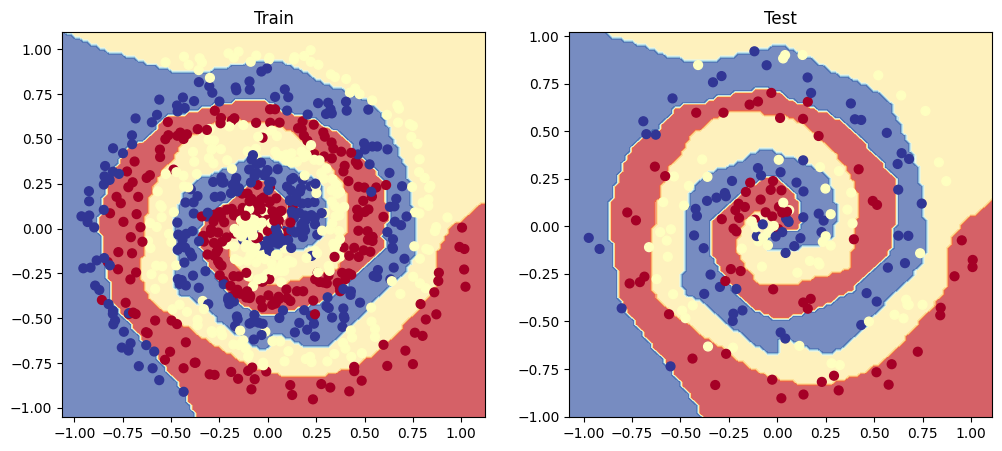

In [86]:
from helper_functions import plot_decision_boundary

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model, x_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model, x_test, y_test)